# Anndata + MOFA2 and objectives of this notebook  

For those who had ever done multi-omics integration, **MOFA2** has become a standard method for dimensionality reduction and visualisation. **MOFA2** can be seen as a generalized sparse principal component analysis. In this notebook I will show how to combine **Anndata** with **MOFA2** for the impact of gastrectomy on microbial and metabolite compositions. Also, I briefly present the **muon** package as a multiomics extension of **Anndata** as it natively implements **MOFA2**. Plots are generated using the **mofax** module. See here for the original paper where the data were generated: 10.1136/gutjnl-2019-319188. 

In [1]:
import anndata 
from mofapy2.run.entry_point import entry_point
import mofax
import pandas as pd 
import numpy as np 
from plotnine import *
from skbio.stats import composition
import muon 
import pylimma as pm 

In [2]:
metadata = pd.read_csv("../data/metadata.tsv", header=0, sep="\t")
species_counts = pd.read_csv("../data/species.counts.tsv", header=0, sep="\t")
metabolites = pd.read_csv("../data/mtb.tsv", header=0, sep="\t")

In [3]:
#Sort values to ensure sample alignment
metadata = metadata.sort_values(by="Sample")
species_counts = species_counts.sort_values(by="Sample")
metabolites = metabolites.sort_values(by="Sample")

species_counts = species_counts.set_index(keys="Sample")
metabolites = metabolites.set_index(keys="Sample")
metadata = metadata.set_index(keys="Sample")

In [4]:
#Creation of the Anndata objects 
#We directly filter and normalize data before subsequent data manipulation

adata_metabolites = anndata.AnnData(X=metabolites, obs=metadata, var=metabolites.columns.to_frame())
bdata_metabolites = adata_metabolites[:,np.sum(adata_metabolites.X == 0, axis=0) < 48]
bdata_metabolites.X = bdata_metabolites.X + 1

bdata_metabolites.layers["Log2"] = np.log2(bdata_metabolites.X)

#Create an additional layer with median normalized signal of log2 transformed metabolites
bdata_metabolites.layers["normalized Log2"] = pm.normalize_median_values(bdata_metabolites.layers["Log2"].T).T

In [5]:
adata_species_counts = anndata.AnnData(X=species_counts, obs=metadata, var=species_counts.columns.to_frame())
bdata_species_counts = adata_species_counts[:,np.sum(adata_species_counts.X == 0, axis=0) < 48]
bdata_species_counts.X = bdata_species_counts.X + 1

bdata_species_counts.layers["clr"] = composition.clr(bdata_species_counts.X)

#Default view are changed using their normalized versions for the sake of simplicity
bdata_species_counts.X = bdata_species_counts.layers["clr"]
bdata_metabolites.X = bdata_metabolites.layers["normalized Log2"]

## MOFA2 with Anndata  

If one wants to use MOFA2 with Anndata object, some modification has to be done to combine the two omics together in the same object. In fact, Anndata is not natively supported by MOFA2 and .X has to be extracted and converted into a numpy array.   

In [6]:
ent = entry_point()

ent.set_data_matrix([[bdata_species_counts.X], [bdata_metabolites.X]], likelihoods=["gaussian","gaussian"], views_names=["microbiome", "metabolites"])
ent.set_model_options(factors=10)
ent.set_train_options(iter=100, convergence_mode="fast")

ent.build()
ent.run()
ent.save(outfile="../data/output_mofa_gastectomy_using_matrix.hdf5") #results were stored as an efficient hdf5 object


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='microbiome' group='group0' with N=96 sample

In [7]:
model_0 = mofax.mofa_model("../data/output_mofa_gastectomy_using_matrix.hdf5")

## MOFA2 with muon  

**muon** is a multi-modal extension of MOFA2. To create a mudata object you simply need to create a dictionnary of anndata object. 

In [8]:
dict_metabolites_species = {"species":bdata_species_counts, "metabolites":bdata_metabolites}

muon_metabolites_species = muon.MuData(dict_metabolites_species)
muon_metabolites_species.obs = bdata_species_counts.obs

We run MOFA2 without specifying the groups_label to run the model blindly to the group. An additional model considering the two groups can also be ran for the supervised version of the model. Models are saved in data/output_mofa_gastectomy_using_muon.hdf5 and data/output_mofa_gastectomy_by_group.hdf5.  

In [9]:
muon.tl.mofa(data=muon_metabolites_species, n_factors=10, outfile="../data/output_mofa_gastectomy_using_muon.hdf5")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='species' group='group1' with N=96 samples and D=6325 features...
Loaded view='metabolites' group='group1' with N=96 samples and D=143 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: Tr

Whenever MOFA2 has been ran, MOFAX can be used for result visualisation. Below I show few basics examples to visualise variance explained and feature contributions.  

In [10]:
#model and vizualise can loaded using mofax
#Model import
model_1 = mofax.mofa_model("../data/output_mofa_gastectomy_using_muon.hdf5")

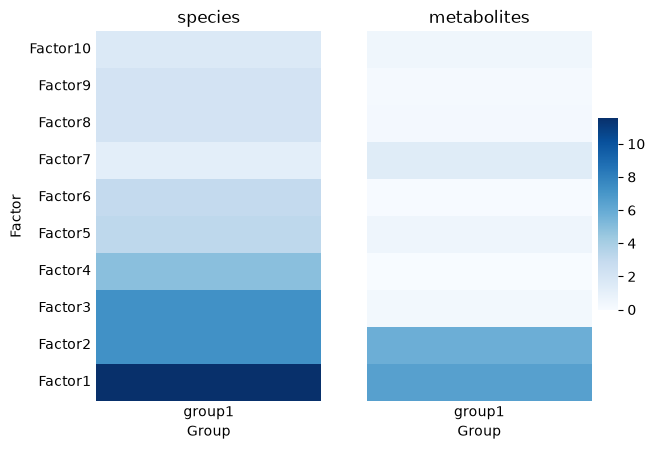

In [11]:
#Variance explained by factor over the two groups
mofax.plot_r2(model_1)

<Axes: xlabel='Factor', ylabel='R2'>

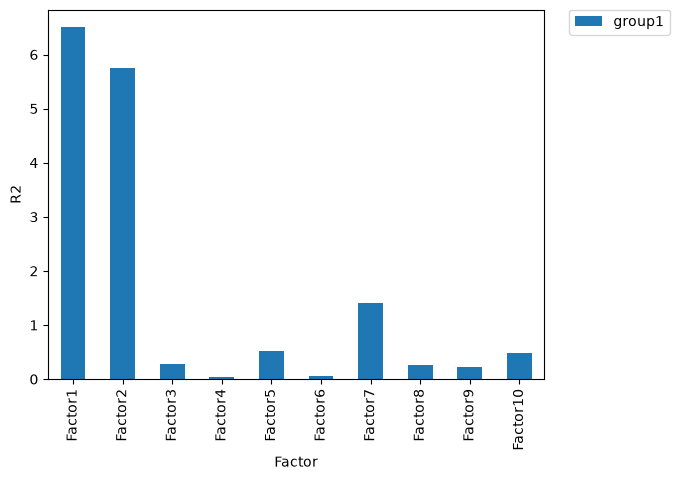

In [12]:
mofax.plot_r2_barplot(model_1, stacked=True, view=1) #or view = 0 for microbiome

Compared to microbiome data where most of the original variance is spread across multiple factors, variance explained by factors over metabolites is concentrated around 2-3 factors.  

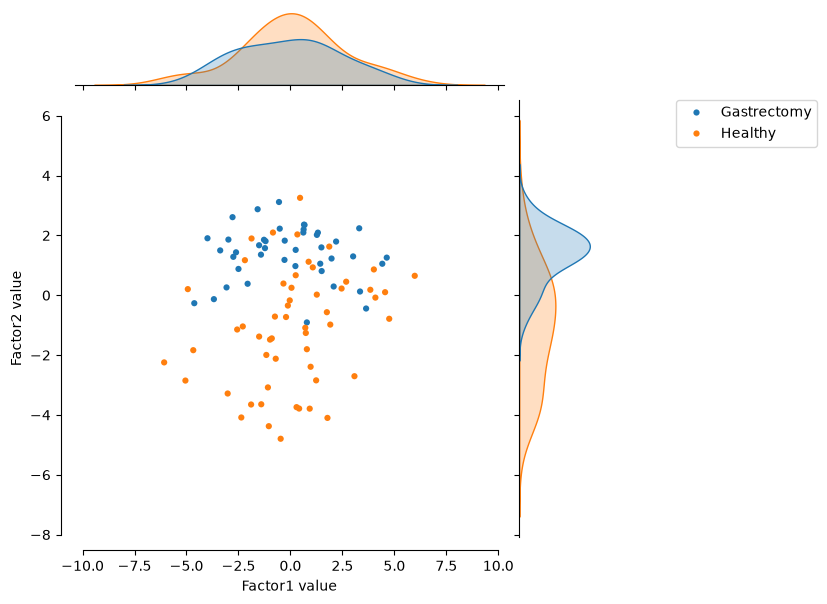

In [13]:
mofax.plot_factors(model_1, color="Study.Group",dist=True)

Jointly considering microbiome and metabolome does not offer clear distinction between study groups.  

## Visualisation of contributive features over factors  

**MOFA2** uses shrinkage to find only the most contributive features over factors. Two options are availabe, either ARD (automatic-relevance determination) or spike-and-slab. Both are bayesian models using Variational Bayes for posterior distribution estimation. You can refer to *ard_weights*, *ard_factors*, *spikeslab_weights* , or *spikeslab_factors* when running the model.


<Axes: title={'center': 'metabolites'}, xlabel='Feature weight'>

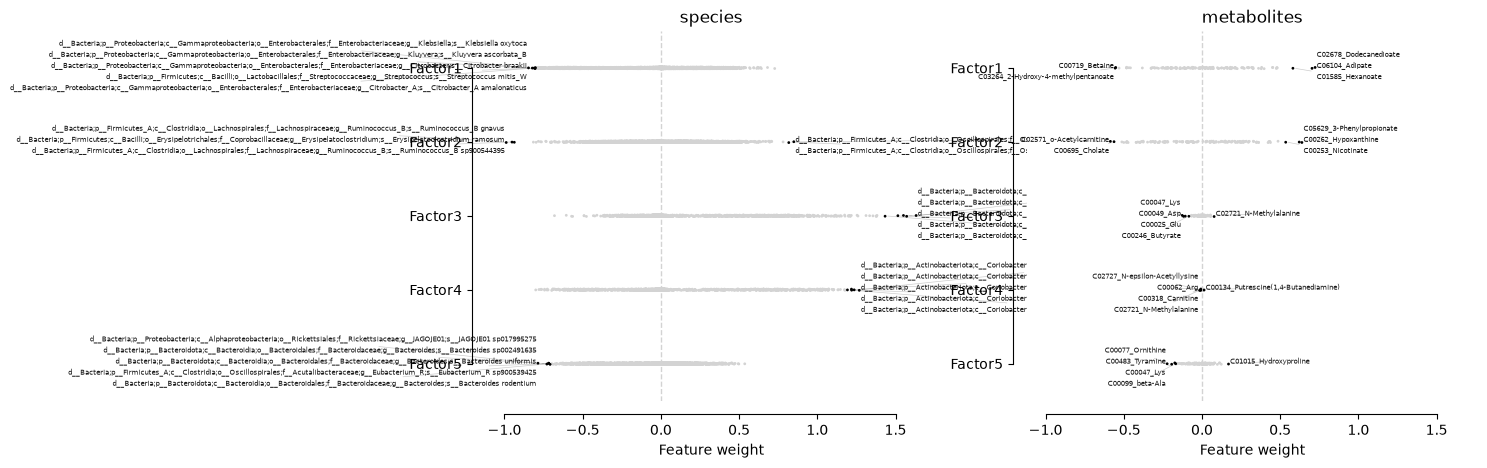

In [14]:
mofax.plot_weights(model_1, factors=range(5))

On the plot above, we highlight only the contributive species and metabolites. Similar visualisation can be obtained using a heatmap.  

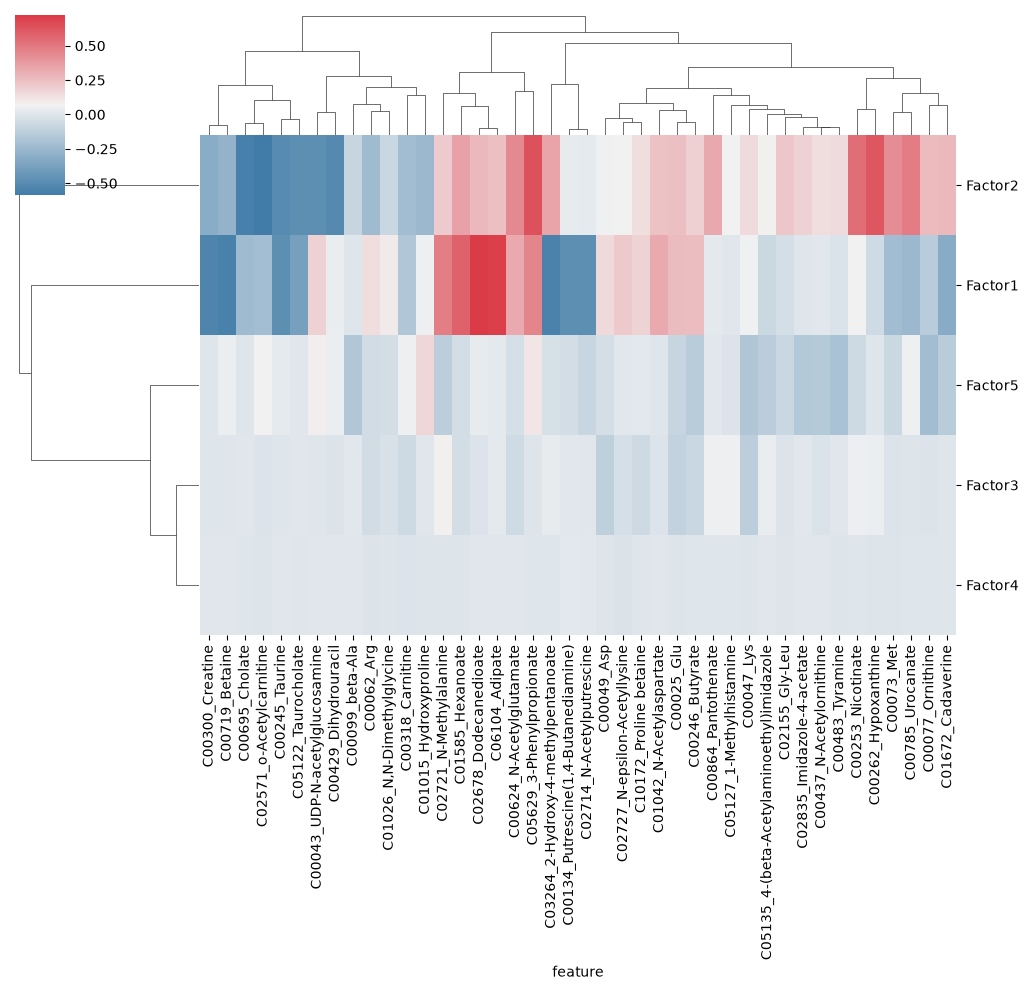

In [15]:
#Contribution of metabolites over factors
mofax.plot_weights_heatmap(model_1, factors=range(0,5),view=1)

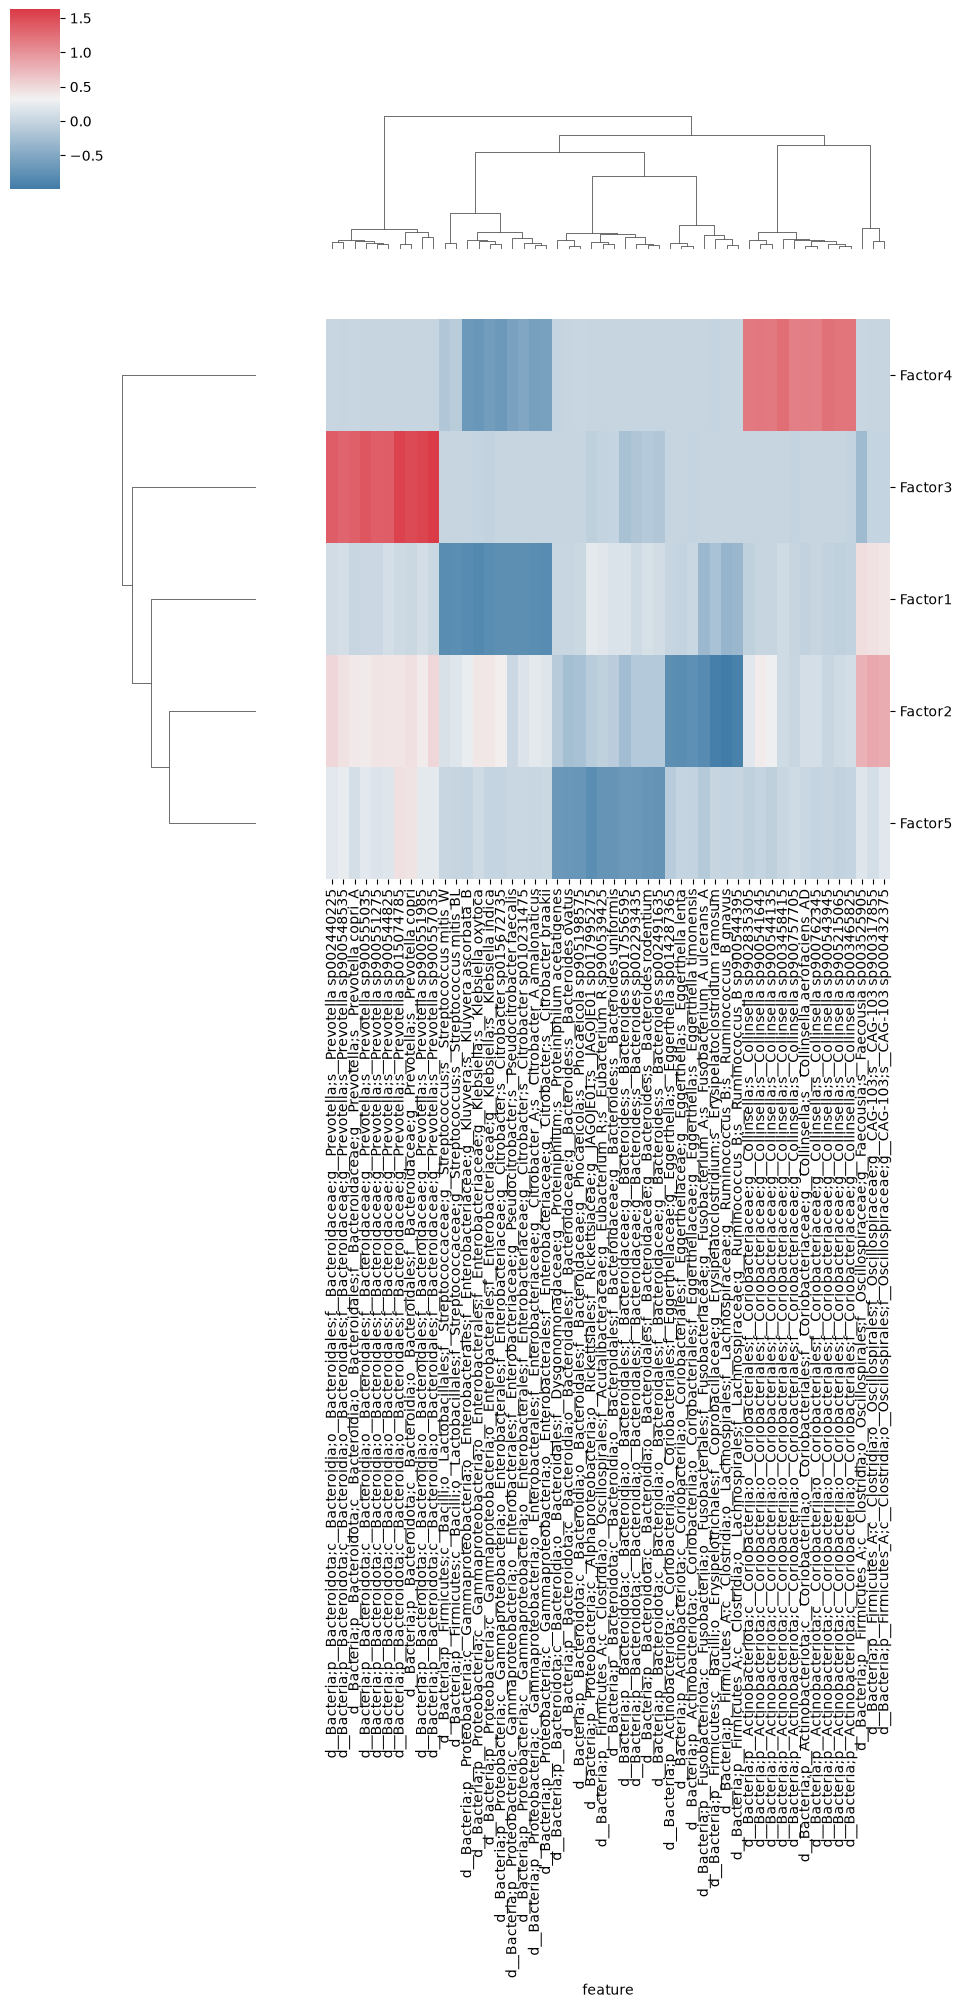

In [16]:
#Contribution of species over factors
mofax.plot_weights_heatmap(model_1, factors=range(0,5),view=0)

The inspection of feature loadings over factors highlight, either species or metabolites that participate to only one factor while some are shared across factors. We can expect that in the latter case, there is correlation between factors where the same features contribute.  

<Axes: >

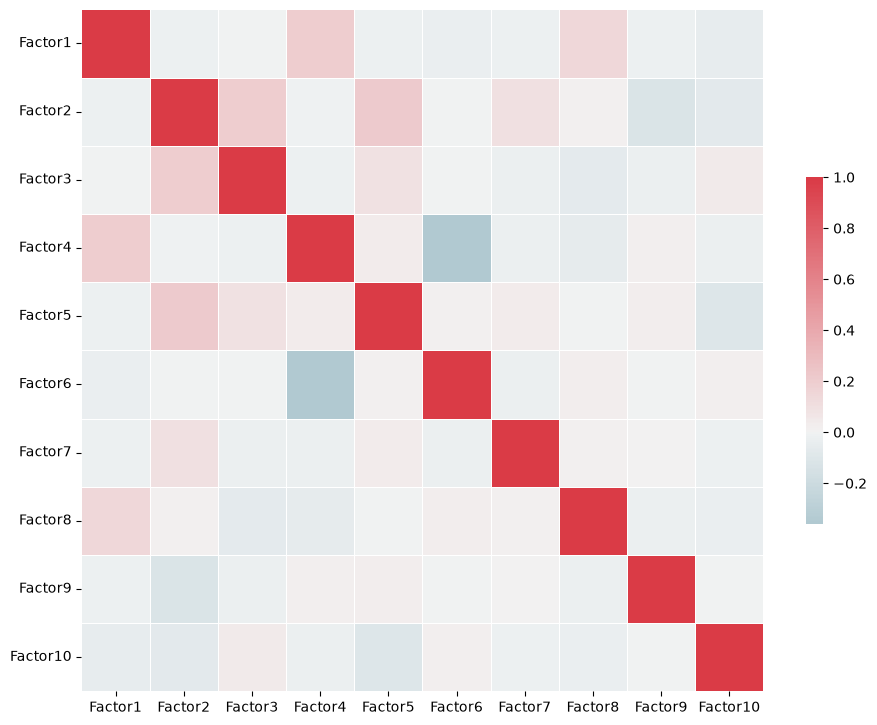

In [18]:
mofax.plot_weights_correlation(model_1, views=0)

<Axes: >

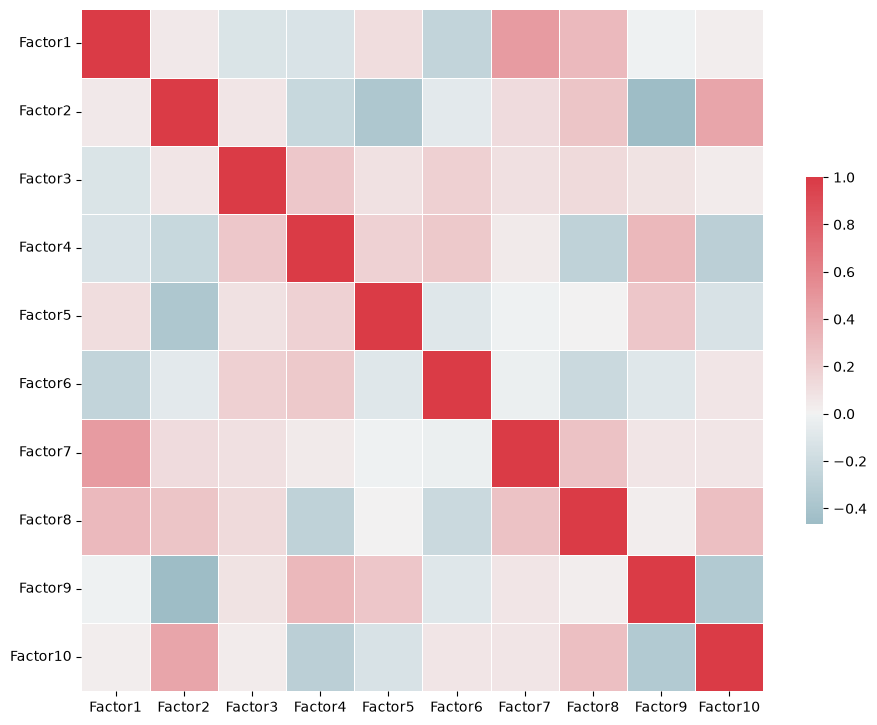

In [19]:
mofax.plot_weights_correlation(model_1, views=1)

On a technical aspect, compared to PCA where principal components are independent, here with **MOFA2** it could exist correlation between factors, suggesting redundancy of information captured by these factors. 

# Conclusion  

In this second notebook we present two implementations of MOFA2, either using **Anndata** objects or **muon**, both leading to the same results. On a practical note, for robust pipelines implementations, I recommend to use as most as possible **muon** as it directly ingests **Anndata** objects and does not require additional data manipulations. **mofax** was also used to visualize results of the model in an efficient and beautiful ways.  